In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import os
import subprocess

In [2]:
reference = "plink/ref_pca.eigenvec"

In [3]:
pd_reference = pd.read_csv(reference, delim_whitespace=True)

C:\Users\sindi\AppData\Local\Temp\ipykernel_21692\3555163820.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd_reference = pd.read_csv(reference, delim_whitespace=True)


In [37]:
targets = glob.glob("dtc_pcs_normalised/genome_*.csv")
all_dfs = []
for f in targets:
    filename = os.path.basename(f)
    parts = filename.split("_")
    name_extracted = f"{parts[1]}_{parts[2]}"
    temp_df = pd.read_csv(f, sep=r',')
    temp_df.insert(0, "Name", name_extracted)
    all_dfs.append(temp_df)
pca = pd.concat(all_dfs, ignore_index=True)

In [38]:
pca

,Name,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,Frances_Stewart,FAM001,ID001,-0.004259,-0.000632,0.000157,0.000081,0.000773,-0.000277,0.004869,0.000704,0.002915,-0.000529,0.009225,-0.001559,0.007101,-0.000310,-0.000393
1,hu24385B_v3,FAM001,ID001,-0.006974,-0.000707,-0.000283,0.001324,0.000405,0.000144,0.002998,0.000949,0.004303,-0.001015,0.010943,-0.002551,0.006319,0.002413,0.001968
2,Jiahao_Huang,FAM001,ID001,-0.006509,0.007970,-0.004372,-0.001623,-0.001588,-0.001039,0.002490,0.000121,0.006095,0.003992,0.008201,-0.002749,0.003863,0.003867,0.001497
3,Joshua_Yoakem,FAM001,ID001,-0.004903,-0.003008,0.002098,-0.001015,0.002686,-0.002153,0.006533,0.001805,0.001112,0.000497,0.010446,0.000768,0.006819,-0.002183,-0.000914
4,Simon_Funk,FAM001,ID001,-0.005047,-0.000514,0.000225,0.000979,0.000340,-0.000157,0.003946,0.000687,0.003134,-0.000781,0.009740,-0.002692,0.006508,0.001434,0.000505
5,Travis_Jupp,FAM001,ID001,-0.004308,0.001294,0.002584,-0.000155,0.000019,-0.000116,0.004951,0.000160,0.003978,0.000737,0.008225,-0.001426,0.008844,0.002006,-0.000314


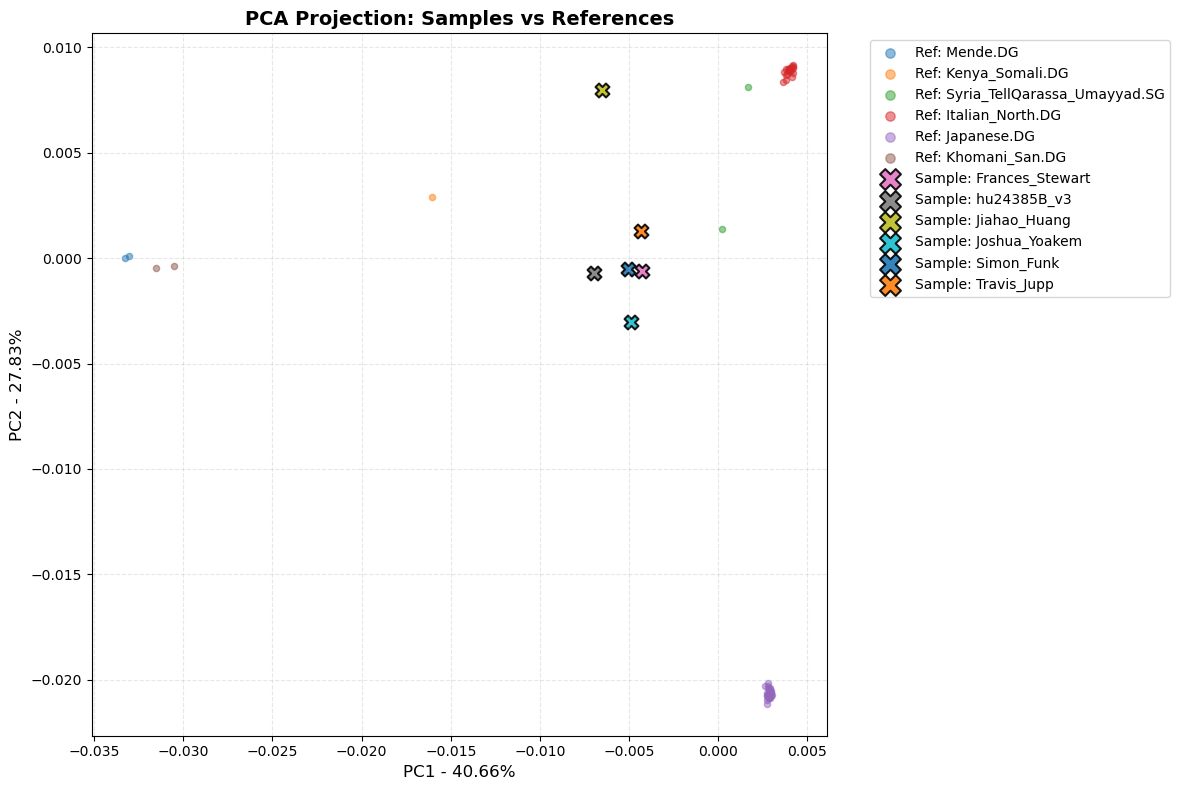

In [39]:
import matplotlib.pyplot as plt

# List of samples with even spread
keep_refs = ["Mende.DG", "Kenya_Somali.DG", "Syria_TellQarassa_Umayyad.SG", 
             "Italian_North.DG", "Japanese.DG", "Khomani_San.DG"]


plt.figure(figsize=(12, 8))

# Plot Reference
for pop in keep_refs:
    sub = pd_reference[pd_reference["#FID"] == pop]
    if not sub.empty:
        plt.scatter(sub["PC1"], sub["PC2"], label=f"Ref: {pop}", s=20, alpha=0.5, marker='o')

# Plot the 23andMe Samples
unique_pca_pops = pca["Name"].unique()
for pop in unique_pca_pops:
    sub_pca = pca[pca["Name"] == pop]
    if not sub_pca.empty:
        plt.scatter(sub_pca["PC1"], sub_pca["PC2"], label=f"Sample: {pop}", s=100, alpha=0.9, marker='X', edgecolors='black', linewidth=1.5)

plt.xlabel("PC1 - 40.66%", fontsize=12)
plt.ylabel("PC2 - 27.83%", fontsize=12) 
plt.title("PCA Projection: Samples vs References", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.5, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

In [41]:
print("Reference Scale: ", pd_reference["PC1"].min(), pd_reference["PC2"].max())
print("Targets Scale: ", pca["PC1"].min(), pca["PC2"].max())

Reference Scale:  -0.0352882 0.0116547
Targets Scale:  -0.0069738966250176 0.0079704223711063
